In [21]:
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature


In [3]:
t = pd.Timestamp("2022-12-16T17:55:05")

In [4]:
zarr = xr.open_dataset("/glade/derecho/scratch/dkimpara/goes-cloud-dataset/goes_10km.zarr")

In [6]:
da = zarr.drop_duplicates("t").sortby("t").sel(t=t, method="nearest").sel(channel=13)

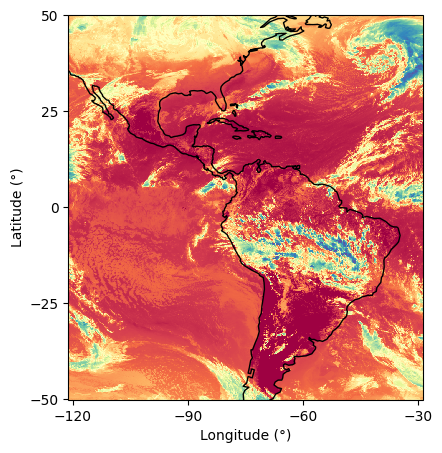

In [30]:

fig = plt.figure(figsize=(5, 5))

# Create axes
ax1 = fig.add_subplot(projection=ccrs.PlateCarree())
da.BT_or_R.plot(ax=ax1, transform=ccrs.PlateCarree(), cmap="Spectral_r", vmax=300, vmin=200,  add_colorbar=False)
ax1.add_feature(cfeature.COASTLINE)
plt.title("")

ax1.set_yticks(list(range(-50,51,25)))
ax1.set_xticks(list(range(-120,-29,30)))

ax1.set_ylabel("Latitude (°)")
ax1.set_xlabel("Longitude (°)")

plt.savefig('data_region.png', dpi=300)